# S&P 500 Equity + Option Analytics: Feasibility Analysis

Before building a trading strategy it is worth asking whether the data can support one at all.
This notebook does that and nothing else: it fits no model and makes no forecast.

The strategy being checked is described in `config/setup.yaml`. Once a week it ranks S&P 500
constituents by a number read off their listed options, and buys the shares at the top of that
ranking. It holds shares, never options: the option market supplies the opinion, and the equity
market is where the position is taken. That file says which stocks it may hold, on which day of
the week it decides, what it assumes a trade costs, and how the history is divided between
designing the strategy and testing it. This notebook checks each of those assumptions against the
data and reports what it finds.

## Learning objectives

By the end of this notebook you will be able to:

- Read an implied volatility off an option surface summary, and find out what a dataset does
  with a calculation that failed before computing anything from the column
- Describe a universe of several hundred stocks by the property the strategy's cost model is
  sensitive to, rather than by counting its members
- Explain why the number of stocks carrying an option quote swings on a monthly cycle, from the
  expiration calendar rather than from anything the strategy does
- See why a charge quoted per share and a charge quoted as a percentage are different assumptions
  about friction, not two units for the same one
- Read off one chart what fraction of price moves are larger than the cost of trading them
- Measure how much of a ranking across stocks is left by the next decision date, computing the
  correlation between two orderings rather than inside a single stock's history
- Check that a walk-forward split fits the history available and leaves the test period unread

## Book reference

Chapter 6, Sections 6.2-6.6. This notebook reads the daily implied volatility surface summary,
daily share prices and `config/setup.yaml`, and writes nothing.

## Prerequisites

None beyond what the sections below define. A reader who has not traded an option will find the
instrument, its price and implied volatility explained where they are first used.

In [1]:
"""S&P 500 Equity + Option Analytics - Feasibility Analysis."""

import datetime as dt
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from IPython.display import display
from ml4t.diagnostic.splitters.calendar import TradingCalendar

from case_studies.utils.feasibility import (
    cross_sectional_persistence,
    exceedance_curve,
    fold_timeline,
)
from data import load_sp500_daily_bars, load_sp500_options_surface
from utils.cv_splits import generate_cv_splits
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE, add_message_title

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "sp500_equity_option_analytics"
START_DATE = "2017-01-01"
END_DATE = "2021-12-31"

## Configuration

Everything the strategy assumes is declared in `config/setup.yaml`, and this notebook reads those
values rather than repeating them, so the two can never disagree. Four groups of settings matter
here, and each one decides something the sections below test.

**How the history is divided.** The sample runs from the start of 2017 to the end of 2021. The
final year is the *holdout*: a stretch of history that is not looked at while the strategy is
being designed, so that when it is finally evaluated there, the result is not a rehearsal of
choices already tuned on the same data. Everything computed in this notebook uses the earlier
part, called the development period, and `evaluation.holdout_start` is where the line falls.

**What the strategy ranks, and what it holds.** The ranking is built from one column of the
option surface summary, the thirty-day at-the-money implied volatility that Section A defines,
and `features.surface` records the contracts it is selected from. A stock is available to rank on
a date only where that number exists for it, which is not every date. From the ranking the
strategy holds the leading names, at most `backtest.sweep.top_k_grid` of them, so that count is
the floor the universe has to clear on a decision date and Section B.2 counts against it.

**What a trade is assumed to cost.** `costs.model` declares a percentage regime: one round-trip
charge in basis points, the same for every stock whatever it costs per share. A basis point is
one hundredth of one percent. Alongside it the sweep carries a per-share regime, where the charge
is a commission plus a half-spread quoted in cents and the percentage follows from the share
price. Section B.3 measures how far apart the two are across this universe.

**What is being predicted, and how it is evaluated.** `labels.primary` names the forward share
return the strategy is trying to rank stocks by, and `labels.horizons` gives every holding period
the design considers. Because a position opened on one decision date is still open on the next,
`labels.buffer` is the separation a walk-forward split has to leave between training and
validation, and Section D reads it.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
SETUP = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

HOLDOUT_START = str(SETUP["evaluation"]["holdout_start"])
HOLDOUT_END = str(SETUP["evaluation"]["holdout_end"])
PRIMARY_LABEL = SETUP["labels"]["primary"]
LABEL_BUFFER = SETUP["labels"]["buffer"]
BUFFER_SESSIONS = int(LABEL_BUFFER.rstrip("D"))
HORIZONS = sorted({int(h.rstrip("D")) for h in SETUP["labels"]["horizons"].values()})
BREADTH_FLOOR = max(SETUP["backtest"]["sweep"]["top_k_grid"][PRIMARY_LABEL])
COST_BPS = SETUP["costs"]["round_trip_cost_bps"]
PER_SHARE = SETUP["costs"]["per_share"]
HALF_SPREADS = SETUP["backtest"]["sweep"]["cost_grid_half_spread_usd"]
ATM_IV = "iv_30_atm"
DTE_LOW, DTE_HIGH = SETUP["features"]["surface"]["dte_buckets"]["30d"]
IV_LAG = int(SETUP["decision"]["iv_feature_lag"].split("_")[0])
IV_STALE = SETUP["features"]["windows"]["iv_forward_fill"]
CALENDAR = TradingCalendar(SETUP["evaluation"]["calendar"])
SESSIONS = CALENDAR.trading_days_between(START_DATE, HOLDOUT_START)
# Persistence is read in decision dates rather than sessions, so the ordering is compared against
# the next decision the strategy takes. Two months of them is long enough to see it flatten.
PERSISTENCE_WEEKS = 8

print(f"Sample: {START_DATE} to {END_DATE}")
print(f"  Development period, used everywhere below:  {START_DATE} to {HOLDOUT_START}")
print(f"  Holdout, not read by this notebook:         {HOLDOUT_START} to {HOLDOUT_END}")
print(
    f"Ranked on: {ATM_IV}, the at-the-money implied volatility of contracts maturing in "
    f"{DTE_LOW} to {DTE_HIGH} days, read {IV_LAG} session late and carried at most {IV_STALE}"
)
print(
    f"Universe: {SETUP['universe']['n_assets']} constituents under "
    f"{SETUP['universe']['eligibility_rule']}, of which the strategy holds up to {BREADTH_FLOOR}"
)
print(
    f"Assumed cost: {SETUP['costs']['model']} regime, {COST_BPS} bps a round trip, against a "
    f"per-share companion of {PER_SHARE} commission plus a half-spread from "
    f"{min(HALF_SPREADS)} to {max(HALF_SPREADS)} dollars"
)
print(
    f"Prediction: {PRIMARY_LABEL}, over horizons of {HORIZONS} sessions, decided at the "
    f"{SETUP['decision']['snapshot']} snapshot and executed at the "
    f"{SETUP['decision']['execution_delay']}"
)
print(
    f"Walk-forward: {SETUP['evaluation']['n_splits']} folds on the "
    f"{SETUP['evaluation']['calendar']} calendar, with {BUFFER_SESSIONS} sessions of separation "
    f"between training and validation"
)

Sample: 2017-01-01 to 2021-12-31
  Development period, used everywhere below:  2017-01-01 to 2021-01-01
  Holdout, not read by this notebook:         2021-01-01 to 2021-12-31
Ranked on: iv_30_atm, the at-the-money implied volatility of contracts maturing in 25 to 35 days, read 1 session late and carried at most 5
Universe: 633 constituents under sp500_with_options, of which the strategy holds up to 20
Assumed cost: percentage regime, 13 bps a round trip, against a per-share companion of 0.0035 commission plus a half-spread from 0.0 to 0.1 dollars
Prediction: fwd_ret_5d, over horizons of [5, 10] sessions, decided at the friday_16:00_et snapshot and executed at the monday_open
Walk-forward: 2 folds on the NYSE calendar, with 10 sessions of separation between training and validation


## A. Orientation

### What the option market is being asked

An option is a contract on a stock. A **call** gives its holder the right to buy the stock at a
fixed price, the **strike**, up to a fixed date, the **expiration**; a **put** gives the right to
sell it on the same terms. The holder pays for that right, and the amount paid is the
**premium**. A contract whose strike sits nearest the current share price is **at the money**.

What a contract is worth depends above all on how far the market expects the stock to travel
before it expires. So the traded premium implies a movement, which is quoted the way
statisticians quote one: as an annualized standard deviation of returns. That number is the
**implied volatility**. It is not a price the exchange publishes; it is solved for, by asking
what volatility would make a pricing model return the premium the contract actually trades at.
Solving can fail, on a contract that has barely traded or whose quotes are crossed, and the
vendor records the failure rather than dropping the row. Section B.1 is where that is handled.

### The one number this strategy reads

A stock has hundreds of listed contracts at any moment, at many strikes and expirations, so a
strategy that wants one number per stock per day has to say which. `features.surface` says: take
the contracts maturing inside the declared day range, take the call and the put nearest the
money, and average their implied volatilities. `materialize_options.py` does that once for the
whole market and writes the daily surface summary this notebook loads. A stock therefore has a
value on a date only if it had a listed expiration inside that maturity window, which is a
property of the option listing calendar rather than of the stock, and Section B.2 is about what
that does to the universe.

### What the strategy does with it

It ranks the stocks by that number and buys the shares of the ones at the top, in equal weights,
holding until the next weekly decision. It never holds an option. Two consequences run through
everything below. Every cost is an ordinary equity trading cost, charged on the share price, not
an option cost charged on a premium. And there is nothing to hedge: a share position's exposure
to the share price is the position, not a side effect of it.

### The three questions this notebook asks

1. **Does the universe exist when the strategy acts?** Decisions are taken once a week, and a
   stock can be ranked only where the option market gave it a value, so enough stocks have to
   carry one on each of those dates to fill the book.
2. **Is a typical move in the share price worth more than it costs to trade?** The declared
   percentage cost charges every stock alike; a per-share charge does not, and the universe runs
   from a few dollars a share to well over a thousand.
3. **Is there enough history to evaluate this honestly?** Enough to split into training and
   validation periods more than once, with the holdout left untouched, and with a gap wide enough
   that a position opened in training does not resolve inside validation.

## B. Universe and cost feasibility

### B.1 Load the data and look at the universe

Two files are loaded: the surface summary, one row per stock and session, and daily share prices.

One property of the implied volatility decides how it may be used. Where the solve described in
Section A did not converge, the vendor records the failure as a negative number rather than as an
empty field, and a difference or ratio taken across tenors inherits it. A negative annualized
standard deviation is not a quantity, and it is worse than a missing one: a drop-missing leaves
it in place, and in a ranking it sorts that stock to the bottom on the strength of a solver
failure rather than a cheap option. `load_sp500_options_surface` returns those placeholders as
missing values, along with every surface measure derived from one, so that this notebook and
every later stage see the same thing. The count of stock-sessions with no value is reported
below; the assertion states the invariant the loader is there to give.

The other assertion is that the summary holds at most one row per stock and session, since a
second would double that stock's weight in every average taken across the panel.

In [4]:
surface = load_sp500_options_surface(start_date=START_DATE, end_date=END_DATE)
bars = load_sp500_daily_bars(start_date=START_DATE, end_date=END_DATE)
development = pl.col("timestamp") < pl.lit(HOLDOUT_START).str.to_date()
quotes = bars.filter(development).select("timestamp", "symbol", "sec_id", "close", "adj_factor")
summary = surface.filter(development)

assert not summary.select(pl.struct("symbol", "timestamp").is_duplicated().any()).item(), (
    "a stock carries more than one surface row on a session"
)
assert summary.select((pl.col(ATM_IV).drop_nulls() > 0).all()).item(), (
    "an implied volatility that is present is not positive"
)

solved = summary.select("timestamp", "symbol", ATM_IV).drop_nulls(ATM_IV)
panel = solved.join(quotes.drop("sec_id"), ["timestamp", "symbol"]).sort(["symbol", "timestamp"])
print(
    f"{panel['symbol'].n_unique()} stocks, {len(panel):,} stock-sessions over "
    f"{panel['timestamp'].n_unique():,} sessions, {panel['timestamp'].min()} to "
    f"{panel['timestamp'].max()}\n"
    f"{summary[ATM_IV].null_count():,} of {len(summary):,} surface rows carry no implied "
    f"volatility, whether unquoted or unsolved"
)

609 stocks, 331,072 stock-sessions over 1,007 sessions, 2017-01-03 to 2020-12-31
92,570 of 423,642 surface rows carry no implied volatility, whether unquoted or unsolved


Six hundred tickers are a list, not a description. The property to sort them by here is the share
price, because Section B.3's subject is that a charge quoted in cents per share and a charge
quoted as a percentage of the trade rank this universe differently, and the price is what
separates them. The table below cuts the universe at fifty, one hundred and two hundred and fifty
dollars a share and reports what each group looks like.

Three things to read off it. The price range across the whole universe spans nearly three orders
of magnitude, which is what makes a fixed charge per share a very different assumption at one end
than at the other. Implied volatility is not ordered by price: the cheapest group and the dearest
group are the two most volatile, so a cost model built on the price is not quietly selecting on
how much the stock moves. And no group is quotable on more than about half the sessions in the
period, which is the listing cycle Section B.2 takes up.

In [5]:
PRICE_CUTS = [50, 100, 250]
band = pl.col("price")
label = pl.when(band < PRICE_CUTS[0]).then(pl.lit(f"under {PRICE_CUTS[0]}"))
for low, high in zip(PRICE_CUTS, PRICE_CUTS[1:], strict=False):
    label = label.when(band < high).then(pl.lit(f"{low} to {high}"))
label = label.otherwise(pl.lit(f"{PRICE_CUTS[-1]} and over"))

n_sessions = quotes["timestamp"].n_unique()
by_symbol = panel.group_by("symbol").agg(
    pl.col("close").median().alias("price"),
    (pl.col(ATM_IV) * 100).median().alias("implied_vol"),
    pl.len().alias("stock_sessions"),
)
groups = (
    by_symbol.with_columns(label.alias("share_price"))
    .group_by("share_price")
    .agg(
        pl.len().alias("stocks"),
        pl.col("price").median().round(0).alias("median_price"),
        pl.col("implied_vol").median().round(1).alias("median_implied_vol_pct"),
        (pl.col("stock_sessions").median() / n_sessions * 100).round(0).alias("pct_of_sessions"),
        pl.col("stock_sessions").sum().alias("stock_sessions"),
    )
    .sort("median_price")
)
with pl.Config(tbl_rows=groups.height, tbl_cols=groups.width):
    display(groups)
print(
    f"Share price across the universe {by_symbol['price'].min():.2f} to "
    f"{by_symbol['price'].max():.2f}, over {n_sessions:,} sessions"
)

share_price,stocks,median_price,median_implied_vol_pct,pct_of_sessions,stock_sessions
str,u32,f64,f64,f64,u32
"""under 50""",183,31.0,28.2,32.0,94522
"""50 to 100""",205,71.0,23.9,32.0,110375
"""100 to 250""",171,143.0,23.3,32.0,98450
"""250 and over""",50,338.0,28.3,47.0,27725


Share price across the universe 3.34 to 1879.53, over 1,007 sessions


### B.2 How many stocks can be ranked when the strategy decides

`setup.yaml::decision.cadence` decides at the last close of each week, so that is where the
universe has to exist. A stock counts on that date under the delay the design assumes: the
surface summary describes the close it is stamped at and is not read until the next session, and
`03_financial_features` carries a value forward over a short gap, so the count below applies that
lag and that tolerance before counting.

The count swings, and the reason is the option listing calendar rather than anything about the
stocks. Every optionable US stock has **monthly** expirations, one in the third week of each
month, on the third Friday or on the session before it when that Friday is a market holiday.
Liquid names additionally have **weekly** expirations on most other Fridays. A stock enters the
summary on a session only if one of its expirations falls inside the maturity window, so on the
sessions when a monthly expiration is inside that window the whole universe qualifies, and on
the rest only the names carrying weeklies do. The figure separates the decision dates on that
basis, asking the question of the session the value was stamped on rather than of the decision
date, because those are one session apart and the answer differs between them.

The maturity window is eleven calendar days wide and a monthly expiration arrives once a month,
so at most one can be inside the window at a time, which the assertion states.

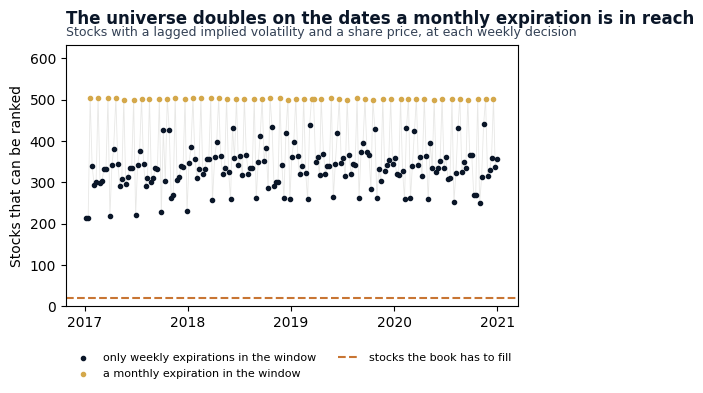

In [6]:
sessions = bars["timestamp"].unique().sort().to_list()
last_session = max(s for s in sessions if s < dt.date.fromisoformat(HOLDOUT_START))


def _monthly_expirations(first: dt.date, last: dt.date) -> set[dt.date]:
    """Third-week expirations, moved back to the previous session on a market holiday."""
    trading = set(sessions)
    dates, day = set(), first
    while day <= last:
        if day.weekday() == 4 and 15 <= day.day <= 21:
            expiry = day
            while expiry not in trading and expiry <= last_session:
                expiry -= dt.timedelta(days=1)
            dates.add(expiry)
        day += dt.timedelta(days=1)
    return dates


monthlies = _monthly_expirations(
    dt.date.fromisoformat(START_DATE), last_session + dt.timedelta(days=DTE_HIGH)
)
in_window = {
    day
    for day in sessions
    if any(day + dt.timedelta(days=k) in monthlies for k in range(DTE_LOW, DTE_HIGH + 1))
}
# The value read at a decision was stamped IV_LAG sessions earlier, so the listing question is
# about that session rather than about the decision date, and the flag is carried forward with it.
listings = (
    pl.DataFrame({"timestamp": sessions})
    .sort("timestamp")
    .with_columns(pl.col("timestamp").is_in(in_window).shift(IV_LAG).alias("monthly_in_window"))
    .drop_nulls("monthly_in_window")
)
assert len({(d.year, d.month) for d in monthlies}) == len(monthlies), (
    "two monthly expirations fall in the same month"
)

rankable = (
    summary.select("timestamp", "symbol", ATM_IV)
    .sort(["symbol", "timestamp"])
    .with_columns(pl.col(ATM_IV).shift(IV_LAG).forward_fill(limit=IV_STALE).over("symbol"))
    .drop_nulls(ATM_IV)
    .join(quotes.select("timestamp", "symbol"), ["timestamp", "symbol"])
)
decisions = rankable.group_by(pl.col("timestamp").dt.truncate("1w")).agg(
    pl.col("timestamp").max().alias("decision_date")
)
entries = rankable.join(decisions, left_on="timestamp", right_on="decision_date").join(
    listings, on="timestamp"
)
# Whether a monthly expiration is in the maturity window is a property of the date rather than of
# the stock, so the two groups are two sets of decision dates, not two parts of one count.
breadth = (
    entries.group_by("timestamp")
    .agg(
        pl.col("symbol").n_unique().alias("n_stocks"),
        pl.col("monthly_in_window").first(),
    )
    .sort("timestamp")
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.plot(breadth["timestamp"], breadth["n_stocks"], color=COLORS["silver_muted"], lw=0.6, zorder=1)
for monthly, color, name in (
    (False, COLORS["blue"], "only weekly expirations in the window"),
    (True, COLORS["amber"], "a monthly expiration in the window"),
):
    group = breadth.filter(pl.col("monthly_in_window") == monthly)
    ax.scatter(group["timestamp"], group["n_stocks"], s=9, color=color, label=name, zorder=2)
ax.axhline(
    BREADTH_FLOOR, color=COLORS["copper"], ls="--", lw=1.5, label="stocks the book has to fill"
)
ax.set_ylim(0, SETUP["universe"]["n_assets"])
ax.set_ylabel("Stocks that can be ranked")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(frameon=False, fontsize=8, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.14))
add_message_title(
    ax,
    "The universe doubles on the dates a monthly expiration is in reach",
    subtitle="Stocks with a lagged implied volatility and a share price, at each weekly decision",
)
plt.show()

Breadth never approaches the floor, so it is not what limits this strategy. What the swing
changes is *which* stocks can be ranked. On the narrow dates the cross-section is about half the
universe and the half that disappears is the less liquid half, so a statistic averaged over
decision dates is an average over two different universes, and the carry-forward tolerance does
not close the gap because the narrow stretches run longer than it does.

### B.3 What a trade costs, and what a move is worth

`setup.yaml::costs.model` declares a percentage regime: one round trip in basis points, charged
alike on every stock. The companion the sweep keeps is a per-share regime, where the charge is a
commission plus a half-spread quoted in cents, so the percentage it works out to depends on the
share price, and a cent is a far larger fraction of a cheap share than of an expensive one.

The curve below states the per-share regime in the percentage regime's units, one point per
stock, ordered by share price. The band spans the declared half-spread grid from its cheapest
rung, which charges commission alone, to its dearest. The flat line is what the percentage regime
charges the same stock. Nominal quoted prices are used, not prices adjusted for splits and
dividends: a commission is charged on the price a share actually traded at.

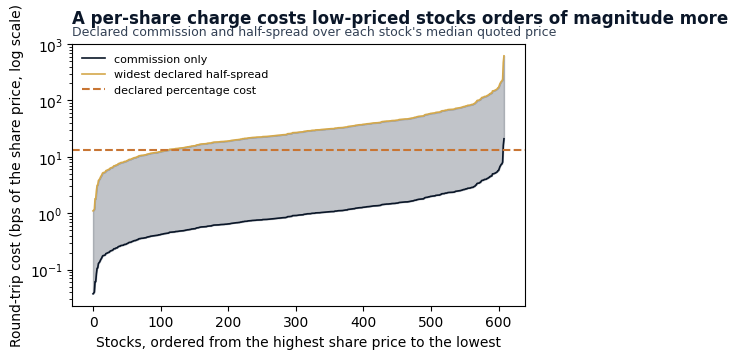

In [7]:
prices = (
    quotes.join(panel.select("symbol").unique(), on="symbol")
    .with_columns((pl.col("close") * pl.col("adj_factor")).alias("adjusted"))
    .sort(["symbol", "sec_id", "timestamp"])
)
cost = (
    prices.group_by("symbol")
    .agg(pl.col("close").median().alias("price"))
    .with_columns(
        (2 * (min(HALF_SPREADS) + PER_SHARE) / pl.col("price") * 1e4).alias("cheapest"),
        (2 * (max(HALF_SPREADS) + PER_SHARE) / pl.col("price") * 1e4).alias("dearest"),
    )
    .sort("price", descending=True)
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
rank = np.arange(len(cost))
ax.fill_between(rank, cost["cheapest"], cost["dearest"], color=COLORS["blue"], alpha=0.25)
ax.plot(rank, cost["cheapest"], color=COLORS["blue"], lw=1.2, label="commission only")
ax.plot(rank, cost["dearest"], color=COLORS["amber"], lw=1.2, label="widest declared half-spread")
ax.axhline(COST_BPS, color=COLORS["copper"], ls="--", lw=1.5, label="declared percentage cost")
ax.set_yscale("log")
ax.set_xlabel("Stocks, ordered from the highest share price to the lowest")
ax.set_ylabel("Round-trip cost (bps of the share price, log scale)")
ax.legend(frameon=False, fontsize=8, loc="upper left")
add_message_title(
    ax,
    "A per-share charge costs low-priced stocks orders of magnitude more",
    subtitle="Declared commission and half-spread over each stock's median quoted price",
)
plt.show()

The band crosses the flat line rather than sitting to one side of it, so no single figure in
cents reproduces the percentage regime across a universe this wide in price. That is why the
percentage regime is the headline and the per-share regime is carried as a companion: the two are
different assumptions about what friction is, and Chapter 18 sweeps both rather than choosing.

Against that cost sits the move in the share price itself. Returns run close to close on the
split- and dividend-adjusted series, and inside one security identity, so that a split does not
enter as a return and a ticker changing hands between two companies does not either. They are
measured over the stock-sessions the strategy could have ranked, which is the population the
question is about: a move in a stock the strategy could not have held that day is not an
opportunity it passed up.

The chart is an **exceedance curve**, and it reads from the right: for each magnitude on the
horizontal axis it gives the fraction of moves at least that large. Where it crosses the cost
line is the fraction of moves bigger than what it costs to trade them. One thing it is not: it
ignores direction entirely, so it is the distribution of how far the share travels, not the
return the strategy would earn. Whether the ranking picks the stocks that travel upward is the
question Chapter 7 onward asks.

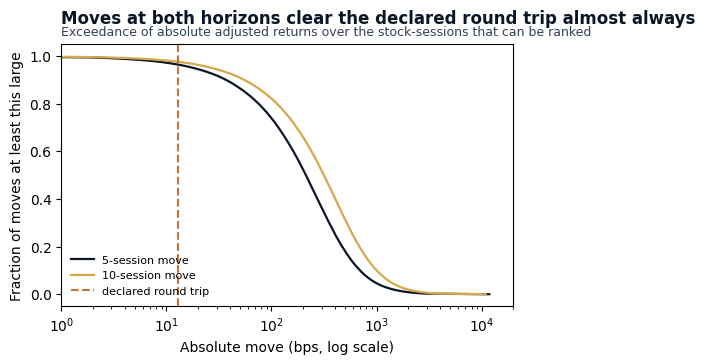

In [8]:
returns = (
    prices.with_columns(
        (pl.col("adjusted").pct_change(h).abs().over(["symbol", "sec_id"]) * 1e4).alias(f"h{h}")
        for h in HORIZONS
    )
    .join(rankable.select("timestamp", "symbol"), ["timestamp", "symbol"])
    .sort(["symbol", "timestamp"])
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for h, color in zip(HORIZONS, (COLORS["blue"], COLORS["amber"]), strict=True):
    magnitude, fraction = exceedance_curve(returns[f"h{h}"].drop_nulls().to_numpy())
    ax.plot(magnitude, fraction, color=color, lw=1.6, label=f"{h}-session move")
ax.axvline(COST_BPS, color=COLORS["copper"], ls="--", lw=1.5, label="declared round trip")
ax.set_xscale("log")
ax.set_xlim(1, 20_000)
ax.set_xlabel("Absolute move (bps, log scale)")
ax.set_ylabel("Fraction of moves at least this large")
ax.legend(frameon=False, fontsize=8, loc="lower left")
add_message_title(
    ax,
    "Moves at both horizons clear the declared round trip almost always",
    subtitle="Exceedance of absolute adjusted returns over the stock-sessions that can be ranked",
)
plt.show()

### B.4 How much of the ranking is left at the next decision

Re-ranking every week is worth the trading it causes only if what the data says on one decision
date still says something on the next. `mapping.entry_logic` acts on a stock's *place* in the
cross-section rather than on its implied volatility as a level, and the two are not the same
thing: every stock's volatility can rise together while the ordering among them is untouched.
So the quantity to measure is the ordering.

The measurement builds the ranking on one decision date, builds it again some number of decision
dates later, and correlates the two over the stocks present on both. Plotted against that number
of weeks, it shows how much of an ordering is still in place and how quickly the rest is
replaced.

It is computed this way, rather than by correlating each stock's own history against itself, for
a reason Section B.2 supplies. A correlation inside a stock needs that stock quoted without
interruption, and here more than two thirds of the universe is missing from the summary on the
narrow dates, so that form would answer the question for the always-quoting minority and discard
everyone the listing cycle actually affects. Comparing two orderings uses whichever stocks are
present on both dates and excludes nobody permanently. The shaded region shows how much the
result varies from one pair of dates to another, and the band around zero shows how large a
correlation could plausibly get between two unrelated orderings of this many stocks.

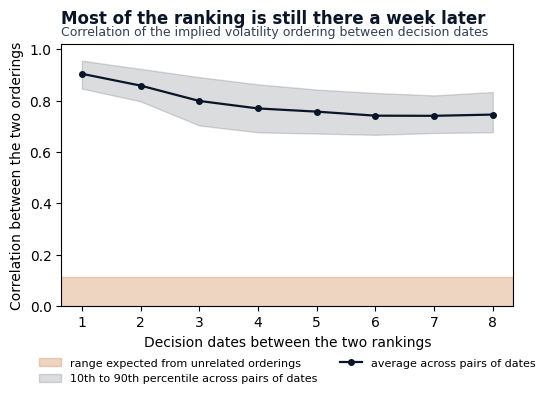

In [9]:
persistence = cross_sectional_persistence(
    entries,
    time_col="timestamp",
    entity_col="symbol",
    value_col=ATM_IV,
    max_lags=PERSISTENCE_WEEKS,
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.axhspan(
    -persistence["band"][0],
    persistence["band"][0],
    color=COLORS["copper"],
    alpha=0.3,
    zorder=1,
    label="range expected from unrelated orderings",
)
ax.fill_between(
    persistence["lag"],
    persistence["rho_p10"],
    persistence["rho_p90"],
    color=COLORS["blue"],
    alpha=0.15,
    zorder=2,
    label="10th to 90th percentile across pairs of dates",
)
ax.plot(
    persistence["lag"],
    persistence["rho"],
    color=COLORS["blue"],
    lw=1.6,
    marker="o",
    ms=4,
    zorder=3,
    label="average across pairs of dates",
)
ax.set_ylim(0, 1.02)
ax.set_xticks(persistence["lag"].to_list())
ax.set_xlabel("Decision dates between the two rankings")
ax.set_ylabel("Correlation between the two orderings")
ax.legend(frameon=False, fontsize=8, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.16))
add_message_title(
    ax,
    "Most of the ranking is still there a week later",
    subtitle="Correlation of the implied volatility ordering between decision dates",
)
plt.show()

### B.5 Move size against cost

Three numbers summarise what B.3 and B.4 drew. The first is the median absolute move over the
primary horizon, as a multiple of the declared round trip, which says how much larger a typical
move is than a typical cost. The second is the fraction of moves larger than that round trip,
which is where the exceedance curve crosses the cost line. The third is how much of the ordering
is left one decision date later.

None of them says the strategy earns anything. A move counts the same whether the share rises or
falls, and a long position is helped by one and hurt by the other. What they rule out is the case
where the design fails immediately, because a typical move is smaller than the cost of taking the
position.

In [10]:
primary = f"h{HORIZONS[0]}"
median_move, above_cost = (
    returns.drop_nulls(primary)
    .select(pl.col(primary).median(), (pl.col(primary) > COST_BPS).mean().alias("share"))
    .row(0)
)
one_week = persistence.filter(pl.col("lag") == 1)["rho"][0]
print(
    f"Median {HORIZONS[0]}-session move {median_move:.0f} bps, {median_move / COST_BPS:.0f}x the "
    f"declared {COST_BPS} bps round trip, and {above_cost:.3f} of moves are larger than it\n"
    f"Priced per share instead, the same round trip runs from {cost['cheapest'].min():.2f} bps on "
    f"the most expensive stock to {cost['dearest'].max():.0f} bps on the cheapest\n"
    f"The ranking correlates {one_week:.2f} with itself one decision date later, "
    f"{persistence['rho'][-1]:.2f} after {PERSISTENCE_WEEKS}"
)

Median 5-session move 213 bps, 16x the declared 13 bps round trip, and 0.965 of moves are larger than it
Priced per share instead, the same round trip runs from 0.04 bps on the most expensive stock to 619 bps on the cheapest
The ranking correlates 0.91 with itself one decision date later, 0.75 after 8


The median absolute five-session move is 213 bps, sixteen times the declared 13 bps round trip,
and 0.965 of moves exceed it. Priced per share instead, the same round trip runs from 0.04 bps on
the most expensive stock to 619 bps on the cheapest. The implied volatility ordering correlates
0.91 with itself one decision date later and 0.75 after eight.

## C. Design decisions

The sections above are evidence. This section is where that evidence meets the choices recorded
in `setup.yaml`, and says what each one rests on.

### C.1 When to decide, and when to trade

`setup.yaml::decision.snapshot` reads the data at the Friday close and
`decision.execution_delay` fills at the following Monday open. Unlike the option-selling case
study alongside this one, this strategy trades shares, and shares have an opening auction, so the
first price a decision taken at Friday's close can reach is Monday's open rather than another
close. `decision.iv_feature_lag` is the other half of the same argument: a surface summary
describes the close it is stamped at and is not published before it, so the ranking is built from
the previous session's value and cannot read a number that did not exist when the decision was
taken.

Section B.4 supports acting weekly rather than daily. Most of the ordering is still there a week
later, so a daily rebalance would pay the spread again for a cross-section that has barely moved;
but enough of it is gone within a few weeks that a monthly rebalance would be acting on a stale
ranking.

### C.2 What would send this design back

A feasibility study is only useful if some result would have stopped it. Three would, and each is
measured where its evidence exists rather than here.

The one this notebook could have produced is a cost failure: if a typical move in the share price
were no larger than what a round trip costs, no ranking would repair that. Section B.5 is that
measurement, and Chapter 18 repeats it against the trades a backtest actually places, sweeping
both cost regimes rather than assuming one.

The other two are outcomes of the strategy rather than properties of the data, and neither can be
settled at this stage. Chapter 7 asks whether the ranking has any relationship at all to the
returns that follow it. Chapter 11 asks the question specific to this case study: the option
market's opinion has to be worth more than the share price history that is free, so the
volatility features have to add something over realized volatility and momentum computed from the
bars alone. If they do not, the option data is an expensive way to rebuild a price signal.

### C.3 What the strategy does with the ranking

`setup.yaml::mapping.class` holds the top of the ranking long and in equal weights. Long-only
keeps borrow and locate frictions out of an example whose subject is the signal, and equal weight
avoids stacking a second optimization on top of the one being tested. Chapter 17 sweeps the
allocators against that baseline.

## D. Walk-forward structure

### D.1 How much an evaluation has to spend

A panel of stock-sessions looks large, but a strategy that decides once a week does not get to
treat every row as an independent opportunity. What it spends is decision dates, and Section B.4
is why even those are worth less than their count suggests: consecutive weeks rank the same
stocks in nearly the same order, so they are not independent draws.

In [11]:
print(
    f"Trading sessions {SESSIONS} | decision dates {len(breadth):,} | stocks per decision date "
    f"{breadth['n_stocks'].min()} to {breadth['n_stocks'].max()}, median "
    f"{breadth['n_stocks'].median():.0f}\n"
    f"Below the {BREADTH_FLOOR} the book needs on "
    f"{breadth.filter(pl.col('n_stocks') < BREADTH_FLOOR).height} of {len(breadth)} decision dates"
)

Trading sessions 1007 | decision dates 209 | stocks per decision date 213 to 503, median 345
Below the 20 the book needs on 0 of 209 decision dates


### D.2 The folds

A model is fitted on one stretch of history and evaluated on the stretch that follows it, then
the pair moves forward and the process repeats. Each fit-then-evaluate pair is a **fold**, and
evaluating this way is called **walk-forward**, because the split always runs in the direction
time does.

One detail decides whether the evaluation is honest. A position opened near the end of a training
block is labelled with a price from after that block ends, so validating on the session
immediately following training would score the model on an outcome it had partly seen. The fix is
to leave a gap between the two at least as wide as the outcome takes to arrive, and that gap is
called **purging**. Its width comes from `labels.buffer`, which `generate_cv_splits` counts in
trading sessions on the calendar `evaluation.calendar` names.

What the splitter is handed is the sessions this panel carries: the dates on which some stock had
both a solved implied volatility and a share price. That is the timeline the later stages build
their folds from as well, because they read the label file, which is written on the same dates
and stops a horizon short of the sample's end since a forward return needs sessions after it. The
splitter numbers folds from the most recent backwards, so they are sorted into time order before
being drawn, and the figure then draws the boundaries it returned rather than recomputing them.

The purge gap is narrow next to training blocks measured in years, so counting it off the session
timeline is the only way to confirm it is as wide as the buffer declares. The three assertions
check that, the fold count, and that no validation window reaches the holdout.

2 folds | purge gap 10 sessions at every boundary, from labels.buffer 10D | last validation ends 2020-12-23, before the holdout opens on 2021-01-01


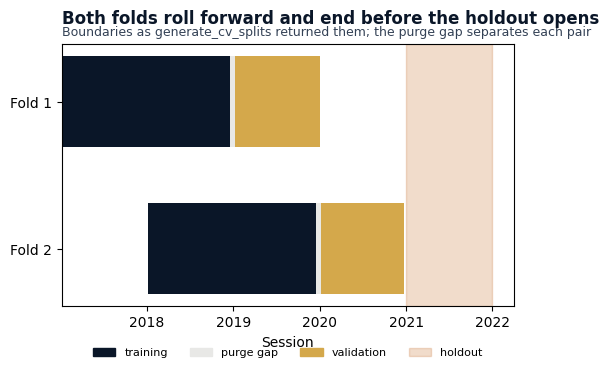

In [12]:
splits = sorted(
    generate_cv_splits(
        panel.select("timestamp"),
        case_study_id=CASE_STUDY_ID,
        label_buffer=LABEL_BUFFER,
        outcome_horizon=SETUP["labels"]["horizons"][PRIMARY_LABEL],
        date_col="timestamp",
    ),
    key=lambda split: split["train_start"],
)
for position, split in enumerate(splits):
    split["fold"] = position

grid = np.sort(panel["timestamp"].unique().to_numpy())
purge_gaps = {
    int(((grid > np.datetime64(s["train_end"])) & (grid < np.datetime64(s["val_start"]))).sum())
    for s in splits
}
last_val = max(split["val_end"] for split in splits)
assert len(splits) == SETUP["evaluation"]["n_splits"], "fold count differs from setup.yaml"
assert last_val < np.datetime64(HOLDOUT_START), "a fold reaches into the holdout"
assert purge_gaps == {BUFFER_SESSIONS}, "a purge gap is not the declared label buffer"
print(
    f"{len(splits)} folds | purge gap {min(purge_gaps)} sessions at every boundary, from "
    f"labels.buffer {LABEL_BUFFER} | last validation ends {last_val.date()}, before the holdout "
    f"opens on {HOLDOUT_START}"
)

fig, ax = plt.subplots(figsize=FIGSIZE["single"])
fold_timeline(ax, splits, holdout=(HOLDOUT_START, HOLDOUT_END))
ax.set_xlabel("Session")
add_message_title(
    ax,
    "Both folds roll forward and end before the holdout opens",
    subtitle="Boundaries as generate_cv_splits returned them; the purge gap separates each pair",
)
plt.show()

## E. What this notebook hands on

Nothing. Membership follows the option listings themselves, as Section B.2 showed, so there is no
eligibility table for a later stage to filter on, and `03_financial_features` rebuilds the same
universe by calling the same two loaders over the same window.

## F. What the evidence says about each setting

One row per setting: the evidence behind it, and the condition under which a reader working on
their own data would choose differently.

| Setting | Evidence | Choose differently when |
|---|---|---|
| `universe.n_assets` | B.2, stocks that can be ranked at each decision date | the count on a decision date falls towards the number of positions the book has to fill |
| `decision.cadence` | B.3 the move distribution, B.4 how long the ordering lasts | the ordering is replaced inside one week, or moves stop clearing the round trip |
| `costs.model` | B.3, the per-share band against the flat percentage line | a measured per-stock spread arrives, which is what would make the per-share regime the headline rather than the companion |
| `evaluation.n_splits` | D.1 decision dates, D.2 the fold boundaries | the folds no longer fit the development period ahead of the holdout |

In [13]:
thin = breadth.filter(pl.col("n_stocks") < BREADTH_FLOOR)
print(
    f"universe.n_assets {SETUP['universe']['n_assets']}, {panel['symbol'].n_unique()} stocks "
    f"quoted a solved implied volatility, {breadth['n_stocks'].min()} to "
    f"{breadth['n_stocks'].max()} of them per decision date, below the {BREADTH_FLOOR} the book "
    f"needs on {thin.height} of {len(breadth)} dates\n"
    f"decision.cadence {SETUP['decision']['cadence']} | decision.execution_delay "
    f"{SETUP['decision']['execution_delay']} | labels.primary {PRIMARY_LABEL} | labels.buffer "
    f"{LABEL_BUFFER}\n"
    f"costs.model {SETUP['costs']['model']} at {COST_BPS} bps; the same round trip charged per "
    f"share spans {cost['cheapest'].min():.2f} to {cost['dearest'].max():.0f} bps across the "
    f"universe\n"
    f"evaluation.n_splits {SETUP['evaluation']['n_splits']}, generated {len(splits)}, last "
    f"validation ends {last_val.date()}, holdout untouched"
)

universe.n_assets 633, 609 stocks quoted a solved implied volatility, 213 to 503 of them per decision date, below the 20 the book needs on 0 of 209 dates
decision.cadence weekly_friday_close | decision.execution_delay monday_open | labels.primary fwd_ret_5d | labels.buffer 10D
costs.model percentage at 13 bps; the same round trip charged per share spans 0.04 to 619 bps across the universe
evaluation.n_splits 2, generated 2, last validation ends 2020-12-23, holdout untouched


609 stocks quote a solved implied volatility over the development period, and between 213 and 503
of them can be ranked on a decision date, against a declared universe of 633 and a book of 20
that no date comes close to failing to fill. The declared 13 bps round trip is the same charge as
anything from 0.04 to 619 bps if it is levied per share instead. Two folds are generated, the
last validation ending 2020-12-23, ten sessions of purging at every boundary.

## Key takeaways

1. **A placeholder is not a measurement.** Where a vendor writes a sentinel value for a
   calculation that failed, a ranking will happily sort on it, because it is a number and a
   drop-missing leaves it in place; find out what a file does with failure before computing
   anything from the column, and normalise it at the loader so every reader gets one answer.
2. **Count the universe on the dates the strategy acts.** Where membership follows a listing
   calendar rather than a liquidity rule, the count cycles for reasons the strategy does not
   control, and an average over all sessions hides it.
3. **Express a cost in the unit it is actually charged in.** A charge per share and a charge as a
   percentage of the trade are different assumptions about friction, and they rank a universe
   spanning three orders of magnitude in price very differently.
4. **Measure the persistence of the thing the strategy acts on.** For a strategy that ranks, that
   is the ordering across entities and not the level inside one, and correlating two orderings
   keeps the entities that come and go, which correlating a single entity's history cannot.
5. **Adjust prices for splits and dividends, and stay inside one security identity**, so that a
   corporate action does not enter the return distribution as a move.

### Known limitations

- Four years of development period, of which the ordering's slow decay makes fewer independent
  observations than the count of decision dates suggests.
- Cost here is the declared commission and half-spread. Market impact needs a position size to be
  expressed against and enters at the cost stage.
- The moves in Section B.3 are unsigned and unconditional. Nothing here says the ranking selects
  the stocks that move upward, which is what Chapter 7 onward measures.
- The implied volatility is read from contracts inside a maturity window rather than at a fixed
  tenor, so a change of expiration moves the series alongside the volatility it is meant to
  measure.

**Next**: labels at the declared horizons, built on this development period.